In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier

In [13]:
import os

In [15]:
os.listdir()

['churn_prediction.ipynb', '.ipynb_checkpoints', 'churn.csv']

In [17]:
df = pd.read_csv('churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [18]:
# checking data types before cleaning
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [19]:
# TotalCharges looks numeric but stored as object → fixing
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [20]:
df = df.dropna()

In [21]:
# converting churn to binary (0 = No, 1 = Yes)
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

In [22]:
# customerID is just an identifier, not useful for prediction
df = df.drop('customerID', axis=1)

In [23]:
# converting categorical variables into numbers
df = pd.get_dummies(df, drop_first=True)

In [24]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [26]:
X.shape, y.shape

((7032, 30), (7032,))

In [27]:
X_train.shape, X_test.shape

((5625, 30), (1407, 30))

In [28]:
from sklearn.ensemble import RandomForestClassifier

# training model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [29]:
y_pred = model.predict(X_test)

In [30]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7853589196872779


In [31]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[930 103]
 [199 175]]


In [32]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.63      0.47      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.68      0.70      1407
weighted avg       0.77      0.79      0.77      1407



In [33]:
import pandas as pd

importances = model.feature_importances_
features = X.columns

feat_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feat_df.head(10)

,Feature,Importance
3,TotalCharges,0.192803
2,MonthlyCharges,0.169677
1,tenure,0.169055
10,InternetService_Fiber optic,0.039889
28,PaymentMethod_Electronic check,0.034498
13,OnlineSecurity_Yes,0.029240
25,Contract_Two year,0.027951
4,gender_Male,0.026993
19,TechSupport_Yes,0.025848
26,PaperlessBilling_Yes,0.025140


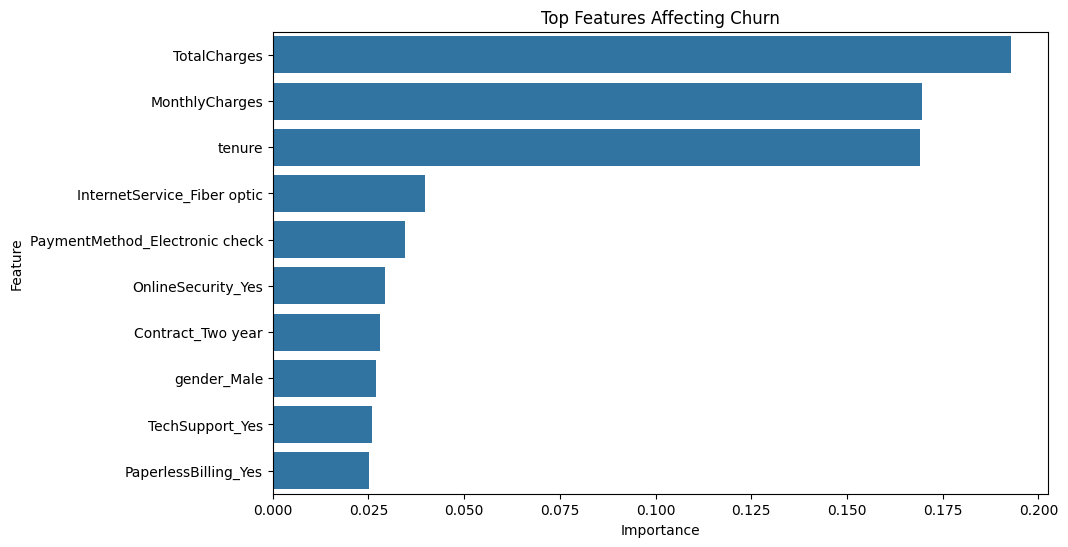

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feat_df.head(10))
plt.title("Top Features Affecting Churn")
plt.show()

In [35]:
print("""
Key Insights:

- Customers with higher monthly charges are more likely to churn
- Customers with shorter tenure are at higher risk of leaving
- Fiber optic users show higher churn, possibly due to higher pricing
- Lack of services like security and tech support increases churn risk

Business Recommendation:

- Offer discounts or incentives for high-paying customers
- Focus on retaining new customers (first few months critical)
- Improve customer support services to reduce churn
""")


Key Insights:

- Customers with higher monthly charges are more likely to churn
- Customers with shorter tenure are at higher risk of leaving
- Fiber optic users show higher churn, possibly due to higher pricing
- Lack of services like security and tech support increases churn risk

Business Recommendation:

- Offer discounts or incentives for high-paying customers
- Focus on retaining new customers (first few months critical)
- Improve customer support services to reduce churn



In [39]:
import os

os.makedirs("output", exist_ok=True)

print(os.listdir())

['churn_prediction.ipynb', 'output', '.ipynb_checkpoints', 'churn.csv']


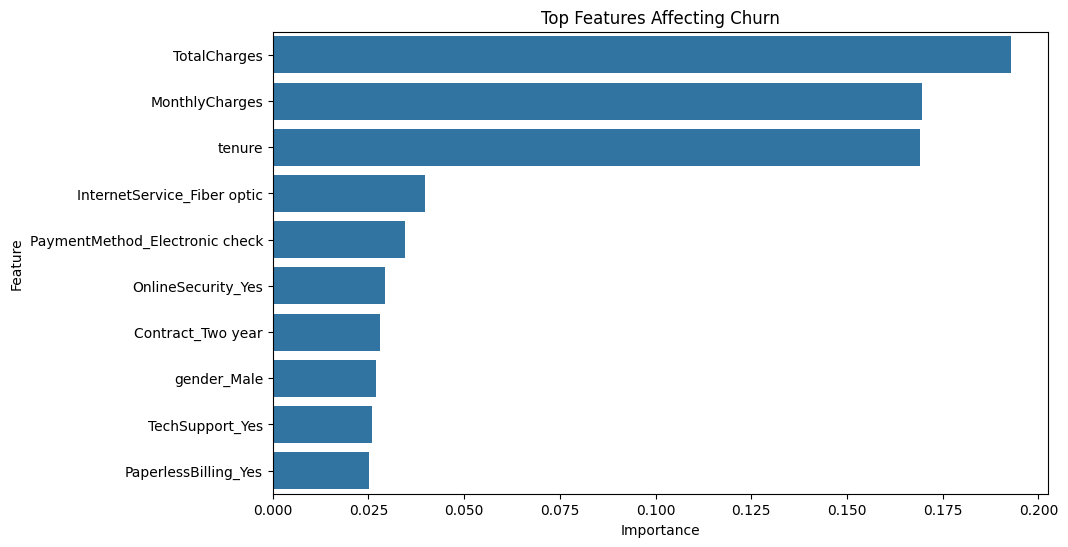

In [40]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("output", exist_ok=True)

fig, ax = plt.subplots(figsize=(10,6))

sns.barplot(x='Importance', y='Feature', data=feat_df.head(10), ax=ax)

ax.set_title("Top Features Affecting Churn")

# 🔥 save using fig (NOT plt)
fig.savefig("output/feature_importance.png")

plt.show()

In [41]:
os.listdir("output")

['feature_importance.png']

In [44]:
print("""
Observation:
- MonthlyCharges and tenure seem important
- Customers with higher charges may be leaving more

Hypothesis:
- Pricing might be a key factor in churn
""")


Observation:
- MonthlyCharges and tenure seem important
- Customers with higher charges may be leaving more

Hypothesis:
- Pricing might be a key factor in churn

